<a href="https://colab.research.google.com/github/georgina-del/Amazon_deforestation_AI4EO/blob/main/Amazon_forest_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Amazon Deforestation Detection using K-Means Unsupervised Learning
### GEOL0069 – AI for Earth Observation | End of Year Project

**Author:** *Georgina Ruber*

**Dataset:** Sentinel-2 SR (Copernicus / Google Earth Engine)

**Study Region:** Rondônia & Pará, Brazilian Amazon

**Temporal Comparison:** 2020 (baseline) → 2024 (recent)

---

## 1. Problem Description


The Amazon rainforest stores 140 billion tonnes of carbon and is the most biodiverse ecosystem on Earth, yet has faced accelerating deforestation since the 1970s, increasing by 34% in 2019 alone (Santos et al., 2024). Recent studies show parts of the Amazon have already shifted from carbon sink to carbon source, while reduced tree cover is altering regional precipitation and increasing wildfire risk (Teixeira et al., 2025). Without effective monitoring, forest loss goes undetected and conservation policy cannot be enforced.

This project applies **K-means unsupervised machine learning** to multi-spectral satellite imagery from
**Sentinel-2** (accessed via Google Earth Engine following the Week 3 course workflow) to:

1. Classify land cover types across two Amazon study regions
2. Detect and quantify forest loss between 2020 and 2024
3. Compare deforestation dynamics between **Rondônia**
   and **Pará**

### Why unsupervised learning?
K-means requires no labelled training data, making it highly applicable in remote regions where
ground truth is scarce.




In [ ]:
# Loading necessary tools and packages

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


## Google Earth Engine Access

This project uses Google Earth Engine (GEE) as a proxy to access Sentinel-2 imagery from the ESA Copernicus browser.

To replicate this:
1. Register at earthengine.google.com
2. Create a Google Cloud project at console.cloud.google.com
3. Enable the Earth Engine API under APIs and Services
4. Replace 'amazon-forest-loss-project' below with your own project ID


In [4]:
# This chunk connects the notebook to the Google Earth Engine so we can access the Sentinel-2 satellite data
ee.Authenticate()


ee.Initialize(project='amazon-forest-loss-project') # This is the Project Id linked to GEE


## Study Regions

Two regions are studied, both roughly 44 x 33 km - the same scale as the Borneo example. Rondonia is highlighted in red on the map below and Para in blue.

In the map of the Amazon below, our region of interest in Rondonia is coloured red and Para in blue.


In [5]:
# Defines the study regions using bounding box coordinates and displays the regions on an interactive map


# This function stores the details of the two study areas (Rondonia and Para) such as their geographic boundaries
study_regions = {
    'rondonia': {
        'geometry': ee.Geometry.Rectangle([-61.3, -11.6, -60.9, -11.3]), # Draws a rectangular bounding box on Earths surface
        'country': 'Brazil',
        'description': 'Rondonia deforestation frontier'
    },
    'para': {
        'geometry': ee.Geometry.Rectangle([-52.4, -3.8, -52.0, -3.5]),
        'country': 'Brazil',
        'description': 'Para primary forest frontier'
    }
}

# Show regions on an interactive map
Map = geemap.Map(center=[-7.5, -57.5], zoom=5)
colours = {'rondonia': 'red', 'para': 'blue'} # Rondonia is depicted in red and Para in blue (see output below)
for name, info in study_regions.items():
    Map.addLayer(info['geometry'], {'color': colours[name]}, name)
Map


Map(center=[-7.5, -57.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Image Preprocessing and Selection

### Cloud Masking Strategy

The Amazon is frequently cloudy, so we use Sentinel-2's Scene Classification Layer (SCL) to remove obvious cloud and shadow pixels. We keep the threshold lenient (up to 50% cloud cover per tile) to maximise available imagery in this tropical region.

### Automated Image Selection

For each region and year, we search the full year and automatically pick the image with the lowest cloud cover percentage. The images use 6 Sentinel-2 bands renamed for clarity.


In [6]:
# Removes the cloud pixels so they dont corrupt the analysis
def mask_sentinel2_clouds(image):
    scl = image.select('SCL') # scene classification layer, where each pixel is labelled what type of surface


    # Exclude: cloud shadow (3), medium cloud (8), high cloud (9), cirrus (10)
    clear_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(clear_mask) # Applies the mask to the actual image

# Searches GEE for the best regional images in the year
def find_best_available_images(region, region_name, year_start, year_end, show_options=True):
    print(f"Finding best available images for {region_name} ({year_start}-{year_end})...")
    # Searches the Sentinel-2 archive and filters them
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterDate(year_start, year_end)
                  .filterBounds(region)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)))


    # Tells you how many images pass the filter
    count = collection.size().getInfo()
    print(f" Found {count} total images")
    if count == 0:
        print(f" No images available for {region_name}")
        return None, None
    if show_options and count > 0:
        print("")
        print(f" Available images for {region_name} ({year_start}-{year_end}):")
        print(f" {'Index':<5} | {'Date':<10} | {'Clouds%':<7} | {'Month':<5} | {'Season'}")
        print(f" {'-'*50}")
        image_list = collection.limit(8).getInfo()
        for i, img in enumerate(image_list['features']):
            props = img['properties']
            cloud_pct = props['CLOUDY_PIXEL_PERCENTAGE']
            date_ms = props['system:time_start']
            date_str = datetime.fromtimestamp(date_ms / 1000).strftime('%Y-%m-%d')
            month = datetime.fromtimestamp(date_ms / 1000).month
            season = "DRY" if month in [6,7,8,9] else "WET" if month in [11,12,1,2,3] else "TRANS"
            print(f" {i:<5} | {date_str} | {cloud_pct:<7.1f} | {month:<5} | {season}")


    # Selects the least cloudy image
    best_image = collection.sort('CLOUDY_PIXEL_PERCENTAGE').first()
    try:
        cloud_pct = best_image.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
        image_date = best_image.get('system:time_start').getInfo()
        readable_date = datetime.fromtimestamp(image_date / 1000).strftime('%Y-%m-%d')
        print(f" AUTO-SELECTED: {readable_date} with {cloud_pct:.1f}% clouds")

        # Applies the cloud mask, selects six bands you need, renames them to readable names
        # Scales down reflectance values
        # Clips the image to the exact study region
        processed = (mask_sentinel2_clouds(best_image)
                     .select(['B2','B3','B4','B8','B11','B12'])
                     .rename(['Blue','Green','Red','NIR','SWIR1','SWIR2'])
                     .multiply(0.0001)
                     .clip(region))

        return processed, readable_date
    except Exception as e:
        print(f" Error: {e}")
        return None, None

In [7]:
# Stores images for both regions searching full year 2020 and 2024
regional_images = {}

print("AMAZON FOREST ANALYSIS - COLLECTING IMAGES")
print("=" * 55)

# the for loop iterates over the two study regions one at a time
for region_name, region_info in study_regions.items():
    print("=" * 50)
    print("COLLECTING IMAGES FOR " + region_name.upper())
    print("=" * 50)

# Finds the best availible images for each region to get the baseline and the most recent image
    baseline_2020, date_2020 = find_best_available_images(
        region_info['geometry'], region_name, '2020-01-01', '2020-12-31'
    )
    recent_2024, date_2024 = find_best_available_images(
        region_info['geometry'], region_name, '2024-01-01', '2024-12-31'
    )
# Checks that both images actually exist
    if baseline_2020 is not None and recent_2024 is not None:
        regional_images[region_name] = {
            'baseline_2020': baseline_2020,
            'recent_2024': recent_2024,
            'geometry': region_info['geometry'],
            'country': region_info['country'],
            'dates': {'2020': date_2020, '2024': date_2024}
# confirms everything worked via feedback messages
        }
        print("SUCCESS: " + region_name + " images collected successfully")
    else:
        print("FAILED: Failed to collect images for " + region_name)

print("Successfully collected images for " + str(len(regional_images)) + " regions!")


AMAZON FOREST ANALYSIS - COLLECTING IMAGES
COLLECTING IMAGES FOR RONDONIA
Finding best available images for rondonia (2020-01-01-2020-12-31)...
 Found 83 total images

 Available images for rondonia (2020-01-01-2020-12-31):
 Index | Date       | Clouds% | Month | Season
 --------------------------------------------------
 0     | 2020-02-02 | 2.0     | 2     | WET
 1     | 2020-02-02 | 9.4     | 2     | WET
 2     | 2020-02-17 | 13.2    | 2     | WET
 3     | 2020-02-17 | 6.6     | 2     | WET
 4     | 2020-03-13 | 20.3    | 3     | WET
 5     | 2020-03-13 | 24.3    | 3     | WET
 6     | 2020-04-07 | 24.9    | 4     | TRANS
 7     | 2020-04-07 | 43.9    | 4     | TRANS
 AUTO-SELECTED: 2020-06-21 with 0.0% clouds
Finding best available images for rondonia (2024-01-01-2024-12-31)...
 Found 66 total images

 Available images for rondonia (2024-01-01-2024-12-31):
 Index | Date       | Clouds% | Month | Season
 --------------------------------------------------
 0     | 2024-01-02 | 36.1  

## Manual Image Selection and Quality Control

The automatic selection picks the least cloudy tile overall, but clouds may still cover your specific study area. Use the function below to manually override the selection by specifying an image index if needed.


In [8]:
# lets you specify which image you want by position

def select_alternative_image_by_index(region_name, region_key, year, date_range, target_index):
    print("Selecting alternative " + str(year) + " image for " + region_name + "...")

    region_geometry = study_regions[region_key]['geometry']
    start_date, end_date = date_range

    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterDate(start_date, end_date)
                  .filterBounds(region_geometry)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 60))
                  .sort('CLOUDY_PIXEL_PERCENTAGE'))

    count = collection.size().getInfo()
    print(" Found " + str(count) + " images in " + start_date + " to " + end_date)

    if count == 0:
        print(" No images available")
        return False

    print(" ALL AVAILABLE OPTIONS (showing up to 10):")
    print(f" {'Idx':<3} | {'Date':<10} | {'Clouds%':<7} | {'Season'}")
    print(f" {'-'*40}")
    image_list = collection.limit(min(count, 10)).getInfo()
    for i, img in enumerate(image_list['features']):
        props = img['properties']
        cloud_pct = props['CLOUDY_PIXEL_PERCENTAGE']
        date_ms = props['system:time_start']
        date_str = datetime.fromtimestamp(date_ms / 1000).strftime('%Y-%m-%d')
        month = datetime.fromtimestamp(date_ms / 1000).month
        season = "DRY" if month in [6,7,8,9] else "WET" if month in [11,12,1,2,3] else "TRANS"
        marker = ">>" if i == target_index else "  "
        print(f"{marker}{i:<3} | {date_str} | {cloud_pct:<7.1f} | {season}")

    if target_index >= count:
        print(" ERROR: Index " + str(target_index) + " too high! Max: " + str(count-1))
        return False

    try:
        selected = ee.Image(collection.toList(count).get(target_index))
        cloud_pct = selected.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
        image_date = selected.get('system:time_start').getInfo()
        readable_date = datetime.fromtimestamp(image_date / 1000).strftime('%Y-%m-%d')
        print(" SELECTING: " + readable_date + " with " + str(round(cloud_pct, 1)) + "% clouds")

        processed = (mask_sentinel2_clouds(selected)
                     .select(['B2','B3','B4','B8','B11','B12'])
                     .rename(['Blue','Green','Red','NIR','SWIR1','SWIR2'])
                     .multiply(0.0001)
                     .clip(region_geometry))

        year_key = 'baseline_2020' if year == 2020 else 'recent_2024'
        regional_images[region_key][year_key] = processed
        regional_images[region_key]['dates'][str(year)] = readable_date
        print(" SUCCESS: " + region_name + " " + str(year) + " image replaced successfully!")
        return True

    except Exception as e:
        print(" ERROR: " + str(e))
        return False


# To override the automatic selection, uncomment and edit the lines below
# select_alternative_image_by_index('Rondonia', 'rondonia', 2020,
#                                   ('2020-01-01', '2020-12-31'), target_index=1)
select_alternative_image_by_index('Para', 'para', 2024,
                              ('2024-01-01', '2024-12-31'), target_index=1)

select_alternative_image_by_index('Para', 'para', 2020,
                                  ('2020-01-01', '2020-12-31'), target_index=1)

print("Manual selection function ready")


Selecting alternative 2024 image for Para...
 Found 50 images in 2024-01-01 to 2024-12-31
 ALL AVAILABLE OPTIONS (showing up to 10):
 Idx | Date       | Clouds% | Season
 ----------------------------------------
  0   | 2024-07-16 | 0.1     | DRY
>>1   | 2024-07-16 | 0.2     | DRY
  2   | 2024-07-21 | 2.3     | DRY
  3   | 2024-09-04 | 2.7     | DRY
  4   | 2024-08-05 | 3.0     | DRY
  5   | 2024-06-21 | 3.5     | DRY
  6   | 2024-06-21 | 4.3     | DRY
  7   | 2024-08-25 | 6.3     | DRY
  8   | 2024-08-25 | 10.6    | DRY
  9   | 2024-06-21 | 10.7    | DRY
 SELECTING: 2024-07-16 with 0.2% clouds
 SUCCESS: Para 2024 image replaced successfully!
Selecting alternative 2020 image for Para...
 Found 57 images in 2020-01-01 to 2020-12-31
 ALL AVAILABLE OPTIONS (showing up to 10):
 Idx | Date       | Clouds% | Season
 ----------------------------------------
  0   | 2020-07-27 | 0.0     | DRY
>>1   | 2020-08-01 | 0.0     | DRY
  2   | 2020-08-06 | 0.0     | DRY
  3   | 2020-07-27 | 0.1     | D

## Visualising the Study Areas


In [9]:
import requests

# Allows you to visually inspect your satellite images before running analysis
def show_all_images_simple(regional_images):
    """Display true-colour RGB composites for all regions and both years."""
    rgb_vis = {'bands': ['Red','Green','Blue'], 'min': 0, 'max': 0.15, 'gamma': 1.4}
    print("AMAZON SATELLITE IMAGES")
    print("=" * 45)
    # Goes through both regions one at a time and displays two images for each one for 2020 and 2024
    for region_name, data in regional_images.items():
        print(region_name.replace('_', ' ').upper())
        print("Country: " + data['country'])
        print("-" * 40)
        # Generates a URL pointing to a rendered image on Googles server
        print("2020 (Baseline):")
        url_2020 = data['baseline_2020'].visualize(**rgb_vis).getThumbURL({
            'region': data['geometry'], 'dimensions': 350, 'format': 'png'
        })
        display(Image(url=url_2020, width=350))
        img_data = requests.get(url_2020).content
        with open(region_name + '_2020.png', 'wb') as f:
            f.write(img_data)
        print("2024 (Recent):")
        url_2024 = data['recent_2024'].visualize(**rgb_vis).getThumbURL({
            'region': data['geometry'], 'dimensions': 350, 'format': 'png'
        })
        display(Image(url=url_2024, width=350))
        img_data = requests.get(url_2024).content
        with open(region_name + '_2024.png', 'wb') as f:
            f.write(img_data)
        print("Images loaded for " + region_name)

show_all_images_simple(regional_images)


AMAZON SATELLITE IMAGES
RONDONIA
Country: Brazil
----------------------------------------
2020 (Baseline):


2024 (Recent):


Images loaded for rondonia
PARA
Country: Brazil
----------------------------------------
2020 (Baseline):


2024 (Recent):


Images loaded for para


## K-Means Clustering Methodology

### Overview

K-means unsupervised classification is used to detect and extract forest cover change from satellite imagery. The approach ensures temporal consistency by training on 2020 data and applying the same model to both time periods, this allows meaningful comparison of pixel counts between the two images.

### Clustering Features

Four vegetation indices are used as input features:

- **NDVI** (Normalised Difference Vegetation Index): Primary vegetation indicator
- **EVI** (Enhanced Vegetation Index): Optimised for dense tropical forests
- **SAVI** (Soil Adjusted Vegetation Index): Reduces soil background effects
- **NDMI** (Normalised Difference Moisture Index): Captures vegetation moisture content

### 1. Training Phase (2020 Data)

- Feature extraction from 2,000 random pixels, all resampled to 30 m
- Optimal cluster selection using silhouette analysis testing 5-7 clusters
- K-means algorithm applied to the training data

### 2. Application Phase (Both Years)

- The same trained model is applied to 2020 and 2024 data
- This enables valid change detection between years

### Land Cover Classification

Labels are assigned to clusters using Amazon-specific NDVI thresholds:

| Land Cover Type | NDVI Range | Description |
|---|---|---|
| Water/Shadow | < 0.1 | Rivers, lakes, burn shadows |
| Bare/Recently Cleared | 0.1 - 0.35 | Active deforestation, bare soil |
| Degraded/Young Plantation | 0.35 - 0.55 | Early regrowth, young cattle pasture |
| Mature Plantation/Degraded Forest | 0.55 - 0.70 | Established agriculture, forest edges |
| Secondary Forest | 0.70 - 0.85 | Regenerating forest |
| Primary Forest | > 0.85 | Dense intact tropical canopy |


In [10]:
# Takes a satellite image and calculates four vegetation indices that will be used as the features for K-means clustering.

def calculate_vegetation_indices(image):

    # NDVI - most important indicator for forest cover
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')

    # EVI - better than NDVI for dense tropical forest
    evi = image.expression(
        '2.5 * ((NIR - Red) / (NIR + 6 * Red - 7.5 * Blue + 1))',
        {'NIR': image.select('NIR'),
         'Red': image.select('Red'),
         'Blue': image.select('Blue')}
    ).rename('EVI')

    # SAVI - reduces soil background effects
    savi = image.expression(
        '((NIR - Red) / (NIR + Red + 0.5)) * 1.5',
        {'NIR': image.select('NIR'),
         'Red': image.select('Red')}
    ).rename('SAVI')

    # NDMI - vegetation moisture content
    ndmi = image.normalizedDifference(['NIR', 'SWIR1']).rename('NDMI')

    return image.addBands([ndvi, evi, savi, ndmi])


In [11]:
def extract_training_pixels(baseline_img, recent_img, region, n_samples=2000):

    print("Extracting training pixels...")

# runs the vegetation index calculation from the previous cell on both 2020 and 2024 images
    baseline_with_indices = calculate_vegetation_indices(baseline_img)
    recent_with_indices   = calculate_vegetation_indices(recent_img)

    # Combine both years - rename 2024 bands to avoid collision
    combined = baseline_with_indices.addBands(
        recent_with_indices.rename([
            'Blue_2024','Green_2024','Red_2024','NIR_2024',
            'SWIR1_2024','SWIR2_2024',
            'NDVI_2024','EVI_2024','SAVI_2024','NDMI_2024'
        ])
    )
# GEE method that randomly picks pixels from across the study
    sample = combined.sample(
        region=region,
        scale=30,
        numPixels=n_samples, # requests 2000 random pixels
        seed=42,
        geometries=True
    )

# downloads the sampled pixel data from GEE's servers to the notebook
    training_data = sample.getInfo()
    print(f"Extracted {len(training_data['features'])} training pixels")

# Turns into a standard pd table where each row is one pixel and each column is one band or vegetation index, this is what k-means will be trained on
    rows = [feat['properties'] for feat in training_data['features']]
    df = pd.DataFrame(rows)
    print("Training data extracted successfully!")
    return df



## Model Training Functions

In [12]:
def perform_consistent_clustering_train_2020(training_df, n_clusters_range=(5, 7)):

    print("Training K-means on 2020 data...")
    print("Will apply same model to both 2020 and 2024 for consistent comparison")

    features_2020 = ['NDVI', 'EVI', 'SAVI', 'NDMI']
    X_2020 = training_df[features_2020].values

    # Remove any pixel rows containing NaN values, which appears where clouds were masked out
    mask_2020 = ~np.isnan(X_2020).any(axis=1)
    X_2020_clean = X_2020[mask_2020]
    print("Using " + str(len(X_2020_clean)) + " clean 2020 pixels for training")

    # Silhouette analysis which is used to find the optimal number of clusters
    # Tests k=5, k=6 , k=7 fitting a k-means model for each, then scoring how well seperated clusters are
    # Then picks the "K" that scored the highest
    silhouette_scores = []
    cluster_range = range(n_clusters_range[0], n_clusters_range[1] + 1)
    print("Testing cluster numbers from " + str(n_clusters_range[0]) + " to " + str(n_clusters_range[1]) + " on 2020 data:")

    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_2020_clean)
        silhouette_avg = silhouette_score(X_2020_clean, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        print(" " + str(n_clusters) + " clusters: Silhouette Score = " + str(round(silhouette_avg, 3)))

    optimal_idx = np.argmax(silhouette_scores)
    optimal_n_clusters = list(cluster_range)[optimal_idx]
    best_silhouette = silhouette_scores[optimal_idx]
    print("Optimal clusters for 2020 training: " + str(optimal_n_clusters) + " (Silhouette: " + str(round(best_silhouette, 3)) + ")")

    final_kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
    cluster_labels_2020 = final_kmeans.fit_predict(X_2020_clean) # trains the final model on the 2020 data and assigns every pixel to a cluster

    return final_kmeans, X_2020_clean, cluster_labels_2020, mask_2020

# then it applies the model to both years

def apply_model_to_both_years(kmeans_model, training_df, mask_2020):

    print("Applying trained model to both 2020 and 2024 data...")

    training_df_clean = training_df[mask_2020].copy()

    X_2020 = training_df_clean[['NDVI','EVI','SAVI','NDMI']].values
    clusters_2020 = kmeans_model.predict(X_2020) # uses predict to assign the pixels to clusters that already exist

    X_2024 = training_df_clean[['NDVI_2024','EVI_2024','SAVI_2024','NDMI_2024']].values
    mask_2024 = ~np.isnan(X_2024).any(axis=1)
    if not mask_2024.all():
        print("Warning: Removing " + str((~mask_2024).sum()) + " pixels with NaN values in 2024 data")
        training_df_clean = training_df_clean[mask_2024]
        X_2024 = X_2024[mask_2024]
        clusters_2020 = clusters_2020[mask_2024]

# adds the cluster assignments as new columns to the data frame
    clusters_2024 = kmeans_model.predict(X_2024)
    training_df_clean['cluster_2020'] = clusters_2020
    training_df_clean['cluster_2024'] = clusters_2024

    print("Successfully classified " + str(len(training_df_clean)) + " pixels for both years")
    return training_df_clean

# translates the raw cluster numbers into meaning land cover labels
def analyze_consistent_clusters(training_df_clean, kmeans_model):

    land_cover_types = [
        "Water/Shadow",
        "Bare/Recently Cleared",
        "Degraded/Young Plantation",
        "Mature Plantation/Degraded Forest",
        "Secondary Forest",
        "Primary Forest"
    ]

    n_clusters = kmeans_model.n_clusters
    cluster_centers = kmeans_model.cluster_centers_ # contains the centroid of each cluster in four dimensional feature space

    cluster_stats = []
    for cluster in range(n_clusters):
        center_ndvi = cluster_centers[cluster][0] # extracts just the NDVI value of each centroid
        count_2020 = (training_df_clean['cluster_2020'] == cluster).sum()
        count_2024 = (training_df_clean['cluster_2024'] == cluster).sum()
        cluster_stats.append((cluster, center_ndvi, count_2020, count_2024))

    cluster_stats.sort(key=lambda x: x[1]) # sorts all clusters from lowest to highest NDVI centroid

    cluster_types = {}
    print("Consistent cluster characteristics (based on 2020 training):")
    print("-" * 75)
    print(f"{'Cluster':<8} {'Land Cover Type':<35} {'Center NDVI':<12} {'2020 Count':<10} {'2024 Count':<10} {'Change'}")
    print("-" * 90)

    for i, (cluster, center_ndvi, count_2020, count_2024) in enumerate(cluster_stats):
        land_cover = land_cover_types[i] if i < len(land_cover_types) else "Other"
        cluster_types[cluster] = land_cover
        change = count_2024 - count_2020
        change_symbol = "+" if change > 0 else ""
        print(f"{cluster:<8} {land_cover:<35} {center_ndvi:<12.3f} {count_2020:<10} {count_2024:<10} {change_symbol}{change}")

    return cluster_types



## Temporal Change Visualisation Functions

In [13]:

# produces side by side chart comaparing 2020 and 2024 land cover
def create_change_analysis_visualization(training_df, cluster_types_2020, cluster_types_2024, region_name):
    """Plot side-by-side bar charts of land cover distribution in 2020 and 2024."""
    print("Creating change analysis for " + region_name + "...")


# a dictionary assigning a specific colour to each land type cover
    colour_map = {
        "Water/Shadow":                       "#000080",
        "Bare/Recently Cleared":              "#8B4513",
        "Degraded/Young Plantation":          "#FFA500",
        "Mature Plantation/Degraded Forest":  "#DAA520",
        "Secondary Forest":                   "#32CD32",
        "Primary Forest":                     "#006400"
    }

# creates a figure with two side by side plots one for 2020 and one for 2024
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(region_name + ' - Land Cover Change Analysis (2020 to 2024)',
                 fontsize=16, fontweight='bold')

# loops over both years, counts how many pixels are in each cluster, looks up land cover label and draws the bars in the correct colours
    total_pixels = len(training_df)

    for ax, year_col, title, cluster_types in [
        (ax1, 'cluster_2020', '2020 Land Cover Distribution', cluster_types_2020),
        (ax2, 'cluster_2024', '2024 Land Cover Distribution', cluster_types_2024)
    ]:
        cluster_counts = training_df[year_col].value_counts().sort_index()
        land_covers    = [cluster_types[i] for i in cluster_counts.index]
        colours        = [colour_map.get(lc, '#808080') for lc in land_covers]

        bars = ax.bar(range(len(cluster_counts)), cluster_counts.values, color=colours)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Number of Pixels')
        ax.set_xticks(range(len(cluster_counts)))
        ax.set_xticklabels([f'C{i}' for i in cluster_counts.index])

        for bar, count, lc in zip(bars, cluster_counts.values, land_covers):
            percentage = (count / total_pixels) * 100
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    str(count) + "\n(" + str(round(percentage, 1)) + "%)",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
            ax.text(bar.get_x() + bar.get_width()/2,
                    -max(cluster_counts.values) * 0.12,
                    lc, ha='center', va='top', fontsize=8, rotation=45)

    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colour_map[lc], label=lc)
                       for lc in colour_map
                       if lc in set(list(cluster_types_2020.values()) + list(cluster_types_2024.values()))]
    fig.legend(handles=legend_elements, loc='lower center', ncol=len(legend_elements),
               bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout()
    plt.show()
    return fig

# calculates and prints summary numbers you saw at the bottom of your results

def print_deforestation_metrics_only(training_df, cluster_types_2020, cluster_types_2024, region_name):
    """Print the key deforestation metrics for a region."""

# loops through cluster labels and counts how many pixels belong to each land type cover
    total_pixels = len(training_df)
    summary_2020 = {}
    summary_2024 = {}

# Where two clusters have the same label (which can happen if k-means produces more clusters than land cover types) their counts get added together.

    for cluster, land_cover in cluster_types_2020.items():
        count = (training_df['cluster_2020'] == cluster).sum()
        summary_2020[land_cover] = summary_2020.get(land_cover, 0) + count

    for cluster, land_cover in cluster_types_2024.items():
        count = (training_df['cluster_2024'] == cluster).sum()
        summary_2024[land_cover] = summary_2024.get(land_cover, 0) + count

    total_forest_loss = total_plantation_gain = total_clearing = 0 # if primary or secondary forest decreased in size
    for land_cover in set(list(summary_2020.keys()) + list(summary_2024.keys())):
        count_2020 = summary_2020.get(land_cover, 0)
        count_2024 = summary_2024.get(land_cover, 0)
        change = count_2024 - count_2020
        if land_cover in ["Primary Forest", "Secondary Forest"] and change < 0:
            total_forest_loss += abs(change)
        elif "Plantation" in land_cover and change > 0:
            total_plantation_gain += change
        elif "Cleared" in land_cover and change > 0:
            total_clearing += change # if recently cleared increased

    print("KEY DEFORESTATION METRICS: " + region_name.upper())
    print("-" * 40)
    print("Total Forest Loss: " + str(total_forest_loss) + " pixels (" + str(round((total_forest_loss/total_pixels)*100, 1)) + "%)")
    print("New Clearing: " + str(total_clearing) + " pixels (" + str(round((total_clearing/total_pixels)*100, 1)) + "%)")
    print("Plantation Expansion: " + str(total_plantation_gain) + " pixels (" + str(round((total_plantation_gain/total_pixels)*100, 1)) + "%)")
    if total_forest_loss > 0:
        annual_loss_rate = (total_forest_loss / total_pixels) * 100 / 4
        print("Annual Deforestation Rate: " + str(round(annual_loss_rate, 2)) + "% per year")


## Rondonia Model Training and Results

In [14]:
# Retrieves the information stored in the rondonia dictionary e.g. images, geometry and dates
rondonia_data = regional_images['rondonia']

training_df_rondonia = extract_training_pixels(
    rondonia_data['baseline_2020'], # The 2020 cloud-masked sentinel-2 images
    rondonia_data['recent_2024'], # The 2024 cloudd-masked sentinel-2 images
    rondonia_data['geometry'], # The bounding box to sample
    n_samples=2000 # Request 2000 random pixes
)

Extracting training pixels...
Extracted 1298 training pixels
Training data extracted successfully!


Training K-means on 2020 data...
Will apply same model to both 2020 and 2024 for consistent comparison
Using 1298 clean 2020 pixels for training
Testing cluster numbers from 5 to 7 on 2020 data:
 5 clusters: Silhouette Score = 0.382
 6 clusters: Silhouette Score = 0.371
 7 clusters: Silhouette Score = 0.383
Optimal clusters for 2020 training: 7 (Silhouette: 0.383)
Applying trained model to both 2020 and 2024 data...
Successfully classified 1298 pixels for both years
Consistent cluster characteristics (based on 2020 training):
---------------------------------------------------------------------------
Cluster  Land Cover Type                     Center NDVI  2020 Count 2024 Count Change
------------------------------------------------------------------------------------------
3        Water/Shadow                        0.298        49         110        +61
2        Bare/Recently Cleared               0.539        133        378        +245
0        Degraded/Young Plantation           

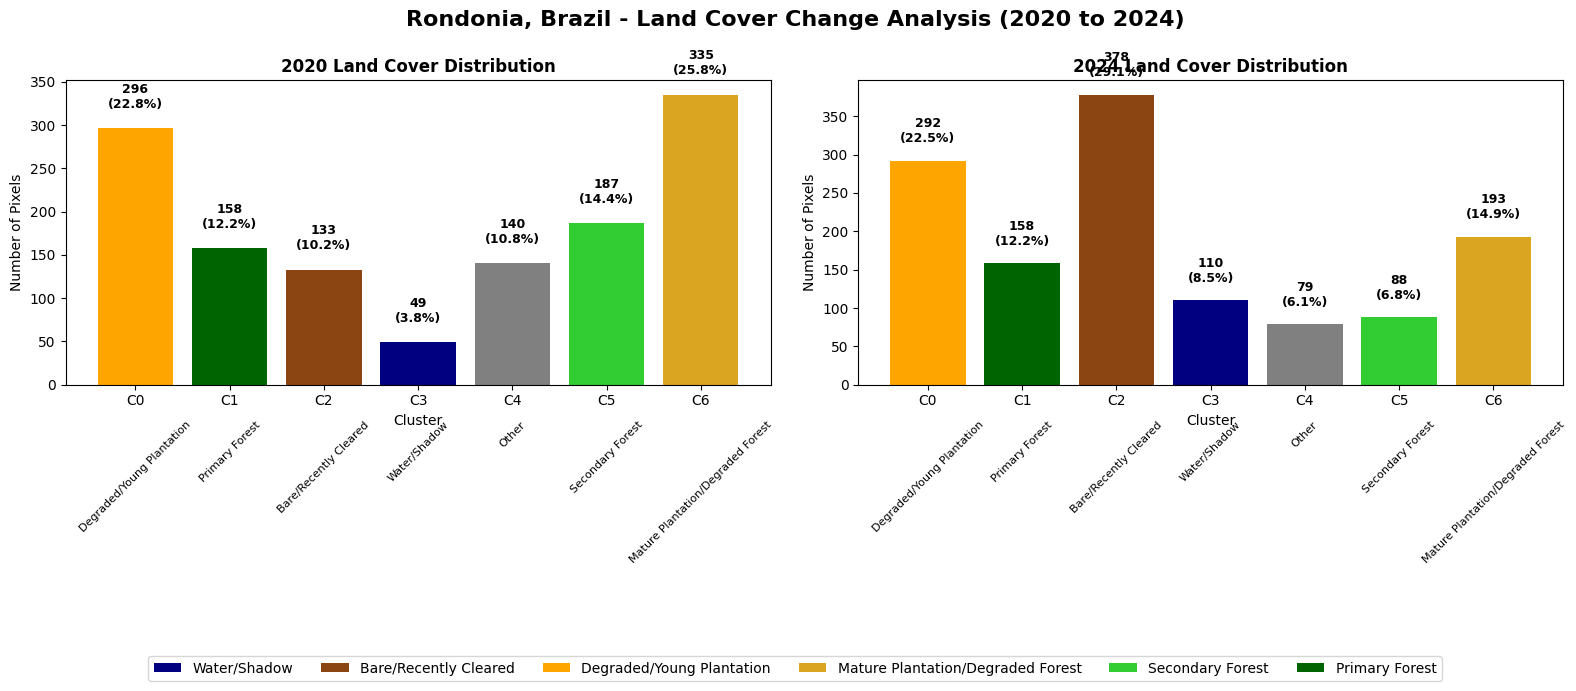

Figure saved: rondonia_land_cover_change.png
KEY DEFORESTATION METRICS: RONDONIA
----------------------------------------
Total Forest Loss: 99 pixels (7.6%)
New Clearing: 245 pixels (18.9%)
Plantation Expansion: 0 pixels (0.0%)
Annual Deforestation Rate: 1.91% per year
Rondonia analysis completed!


In [15]:
# This function runs the k-means training on the rondonia 2020 pixel data
rondonia_kmeans_model, rondonia_X_2020, rondonia_labels_2020, rondonia_mask = perform_consistent_clustering_train_2020(
    training_df_rondonia, n_clusters_range=(5, 7)
)
# Takes the trained model and applies it to both years using the same cluster boundaries
training_df_rondonia_consistent = apply_model_to_both_years(
    rondonia_kmeans_model, training_df_rondonia, rondonia_mask
)
cluster_types_rondonia = analyze_consistent_clusters( # dictionary mapping each cluster to its label
    training_df_rondonia_consistent, rondonia_kmeans_model
)
# Generates the side by side bar charts comparing the 2020 and 2024 land cover distributions
print("Creating change analysis visualization for Rondonia...")
fig_rondonia = create_change_analysis_visualization(
    training_df_rondonia_consistent,
    cluster_types_rondonia,
    cluster_types_rondonia,
    "Rondonia, Brazil"
)
# Save the figure before it gets cleared from memory
fig_rondonia.savefig('rondonia_land_cover_change.png', dpi=150, bbox_inches='tight')
print("Figure saved: rondonia_land_cover_change.png")
# This prints the summary numbers containing total forest loss, new clearing, plantation expansion and annual deforestation rates
print_deforestation_metrics_only(
    training_df_rondonia_consistent,
    cluster_types_rondonia,
    cluster_types_rondonia,
    "Rondonia"
)
print("Rondonia analysis completed!")



## Para Model Training and Results

In [16]:
# Retrieves the information stored in the Para dictionary e.g. images, geometry and dates
print("Extracting training data for Para...")
para_data = regional_images['para']

training_df_para = extract_training_pixels(
    para_data['baseline_2020'], # The 2020 cloud-masked sentinel-2 images
    para_data['recent_2024'], # The 2024 cloudd-masked sentinel-2 images
    para_data['geometry'], # The bounding box to sample
    n_samples=2000 # Request 2000 random pixes
)
print("Para training data ready!")


Extracting training data for Para...
Extracting training pixels...
Extracted 596 training pixels
Training data extracted successfully!
Para training data ready!


Training K-means on 2020 data...
Will apply same model to both 2020 and 2024 for consistent comparison
Using 596 clean 2020 pixels for training
Testing cluster numbers from 5 to 7 on 2020 data:
 5 clusters: Silhouette Score = 0.476
 6 clusters: Silhouette Score = 0.408
 7 clusters: Silhouette Score = 0.376
Optimal clusters for 2020 training: 5 (Silhouette: 0.476)
Applying trained model to both 2020 and 2024 data...
Successfully classified 596 pixels for both years
Consistent cluster characteristics (based on 2020 training):
---------------------------------------------------------------------------
Cluster  Land Cover Type                     Center NDVI  2020 Count 2024 Count Change
------------------------------------------------------------------------------------------
3        Water/Shadow                        -0.240       9          9          0
2        Bare/Recently Cleared               0.433        73         54         -19
1        Degraded/Young Plantation           0.610

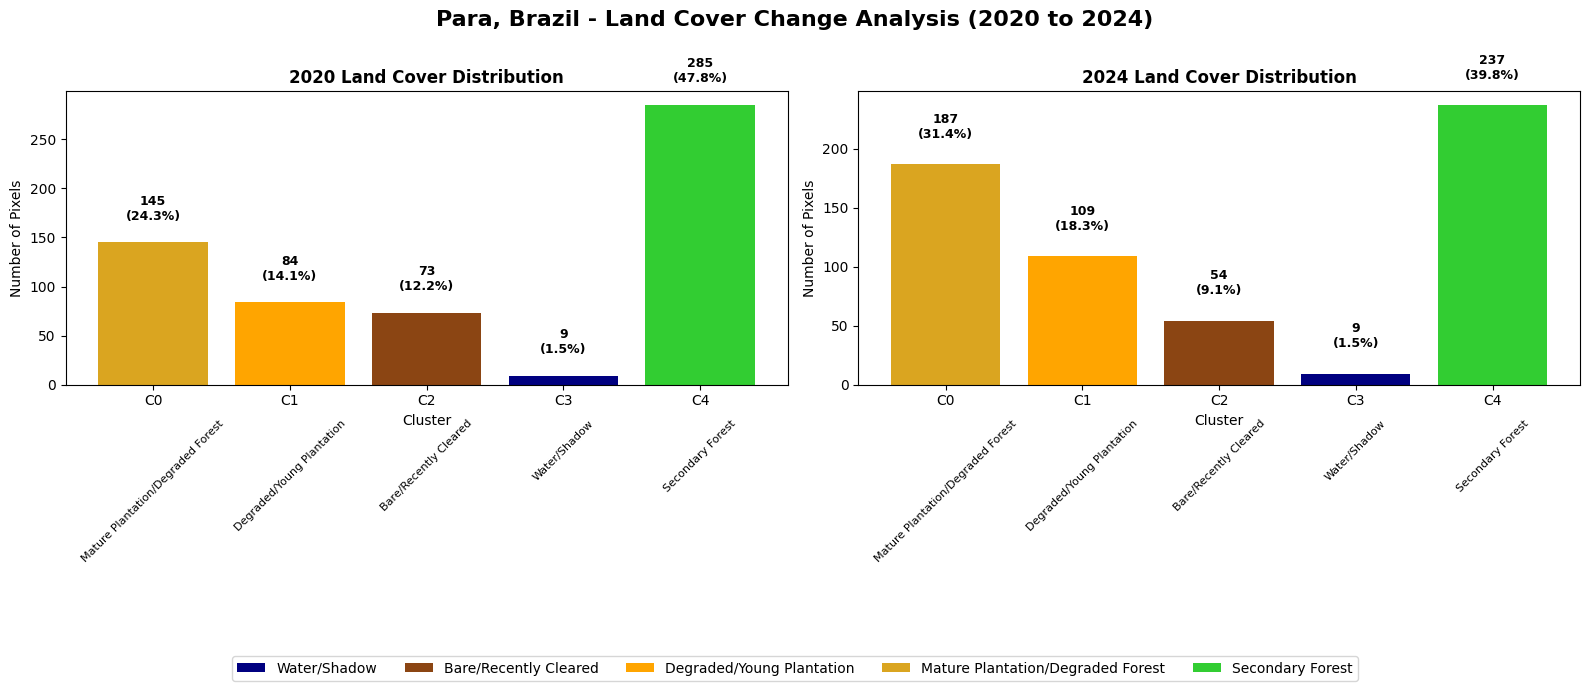

Figure saved: para_land_cover_change.png
KEY DEFORESTATION METRICS: PARA
----------------------------------------
Total Forest Loss: 48 pixels (8.1%)
New Clearing: 0 pixels (0.0%)
Plantation Expansion: 67 pixels (11.2%)
Annual Deforestation Rate: 2.01% per year


In [18]:


# This function runs the k-means training on the Para 2020 pixel data
para_kmeans_model, para_X_2020, para_labels_2020, para_mask = perform_consistent_clustering_train_2020(
    training_df_para, n_clusters_range=(5, 7)
)

# Takes the trained model and it to both years using the same cluster boundaries
training_df_para_consistent = apply_model_to_both_years(
    para_kmeans_model, training_df_para, para_mask
)

cluster_types_para = analyze_consistent_clusters( # dictionary mapping each cluster to its label
    training_df_para_consistent, para_kmeans_model
)
# Generates the side by side bar charts comparing th 2020 and 2024 land cover distribtuions
print("Creating change analysis visualization for Para...")
fig_para = create_change_analysis_visualization(
    training_df_para_consistent,
    cluster_types_para,
    cluster_types_para,
    "Para, Brazil"
)
# Save the figure
fig_para.savefig('para_land_cover_change.png', dpi=150, bbox_inches='tight')
print("Figure saved: para_land_cover_change.png")
# This prints the summary number containing total forest loss, new clearing, plantation expansion and annual deforestation rates
print_deforestation_metrics_only(
    training_df_para_consistent,
    cluster_types_para,
    cluster_types_para,
    "Para"
)

